<div dir="rtl" style="text-align: right;">

# پاکسازی و آماده‌سازی داده‌ها: آموزش جامع برای تدریس

این فایل آموزشی به موضوع **پاکسازی و آماده‌سازی داده‌ها** اختصاص دارد و برای تدریس طراحی شده است. محتوا شامل توضیحات نظری، مثال‌های عملی، و پیاده‌سازی کدها در پایتون با استفاده از کتابخانه **Pandas** است. هدف، آموزش تکنیک‌های پاکسازی و آماده‌سازی داده‌ها برای تحلیل دقیق‌تر و بهبود کیفیت داده‌هاست.

---
<div/>

<div dir="rtl" style="text-align: right;">

## ۱. مقدمه‌ای بر پاکسازی و آماده‌سازی داده‌ها

پاکسازی و آماده‌سازی داده‌ها (Data Cleaning and Preparation) فرآیند اصلاح، حذف، یا تبدیل داده‌های خام برای آماده‌سازی آن‌ها برای تحلیل است. این مرحله معمولاً 60-80٪ زمان پروژه‌های داده‌محور را به خود اختصاص می‌دهد.

**چرا مهم است؟**
- داده‌های ناقص، پرت، یا ناسازگار می‌توانند نتایج تحلیل را مخدوش کنند.
- آماده‌سازی صحیح داده‌ها دقت مدل‌های یادگیری ماشین و تحلیل‌ها را افزایش می‌دهد.
- داده‌های تمیز و استاندارد به تصمیم‌گیری بهتر کمک می‌کنند.

**موضوعات این بخش**:
1. حذف داده‌های ناقص یا پرت (Null, Outliers)
2. فیلتر کردن، شرط‌گذاری، و انتخاب داده‌ها
3. تبدیل نوع داده‌ها، استانداردسازی، و نرمالسازی
4. ساخت ستون جدید، استفاده از `map` و `apply` در Pandas

---
<div/>

## ۲. حذف داده‌های ناقص یا پرت (Null, Outliers)

<div dir="rtl" style="text-align: right;">

### ۲.۱. داده‌های ناقص (Null/Missing Values)
داده‌های ناقص (مانند مقادیر `NaN` یا `None`) می‌توانند به دلایل مختلفی مثل خطای جمع‌آوری داده یا ناقص بودن منبع ایجاد شوند.

**روش‌های برخورد با داده‌های ناقص**:
- **حذف**: حذف ردیف‌ها یا ستون‌هایی که مقادیر ناقص دارند (اگر درصد کمی از داده‌ها ناقص باشند).
- **جایگزینی**: پر کردن مقادیر ناقص با میانگین، میانه، مد، یا مقادیر ثابت.
- **پر کردن پیش‌رو/پس‌رو**: استفاده از مقادیر قبلی یا بعدی برای پر کردن.
۱. پیش‌رو (Forward Fill - ffill)

معنی: مقادیر ناقص (NaN) با مقدار قبلی (بالاترین مقدار غیرناقص در همان ستون یا ردیف) جایگزین می‌شوند.
چگونه کار می‌کند: از بالا به پایین (یا از چپ به راست، بسته به جهت) حرکت می‌کند و هر NaN را با آخرین مقدار معتبر قبل از آن پر می‌کند.
کاربرد: مناسب برای داده‌هایی که ترتیب زمانی یا ترتیبی دارند (مثل سری‌های زمانی که انتظار می‌رود مقدار قبلی ادامه داشته باشد).

پس‌رو (Backward Fill - bfill)

معنی: مقادیر ناقص (NaN) با مقدار بعدی (پایین‌ترین مقدار غیرناقص در همان ستون یا ردیف) جایگزین می‌شوند.
چگونه کار می‌کند: از پایین به بالا (یا از راست به چپ، بسته به جهت) حرکت می‌کند و هر NaN را با اولین مقدار معتبر بعد از آن پر می‌کند.
کاربرد: مناسب برای مواردی که انتظار می‌رود مقدار بعدی نماینده بهتری برای داده ناقص باشد.

تفاوت کلیدی

جهت پر کردن:

ffill (پیش‌رو): از مقدار قبلی (بالا یا چپ) استفاده می‌کند.
bfill (پس‌رو): از مقدار بعدی (پایین یا راست) استفاده می‌کند.


کاربرد عملی:

ffill برای داده‌هایی که روند گذشته مهم است (مثل قیمت سهام).
bfill برای داده‌هایی که مقدار آینده مرتبط‌تر است (مثل پیش‌بینی‌های بعدی).

**مثال عملی**:
فرض کنید یک مجموعه داده فروش داریم با برخی مقادیر ناقص.
<div/>

In [ ]:
import pandas as pd
import numpy as np

# داده‌های نمونه
data = pd.DataFrame({
    'نام': ['علی', 'مریم', 'رضا', 'سارا'],
    'سن': [25, np.nan, 30, 28],
    'فروش': [100, 150, np.nan, 200]
})

print("داده اولیه:\n", data)

# شناسایی مقادیر ناقص
print("\nتعداد مقادیر ناقص:\n", data.isna().sum())

# حذف ردیف‌های دارای ناقص
data_dropped = data.dropna()
print("\nبعد از حذف ردیف‌های ناقص:\n", data_dropped)

# پر کردن ناقص‌ها با میانگین
data_filled = data.fillna({'سن': data['سن'].mean(), 'فروش': data['فروش'].mean()})
print("\nبعد از پر کردن با میانگین:\n", data_filled)

# پر کردن پیش‌رو
data_ffill = data.fillna(method='bfill')
print("\nبعد از پر کردن پیش‌رو:\n", data_ffill)

داده اولیه:
     نام    سن   فروش
0   علی  25.0  100.0
1  مریم   NaN  150.0
2   رضا  30.0    NaN
3  سارا  28.0  200.0

تعداد مقادیر ناقص:
 نام     0
سن      1
فروش    1
dtype: int64

بعد از حذف ردیف‌های ناقص:
     نام    سن   فروش
0   علی  25.0  100.0
3  سارا  28.0  200.0

بعد از پر کردن با میانگین:
     نام    سن   فروش
0   علی  25.0  100.0
1  مریم  28.0  150.0
2   رضا  30.0  150.0
3  سارا  28.0  200.0

بعد از پر کردن پیش‌رو:
     نام    سن   فروش
0   علی  25.0  100.0
1  مریم  30.0  150.0
2   رضا  30.0  200.0
3  سارا  28.0  200.0


C:\Users\karvarz\AppData\Local\Temp\ipykernel_7688\230597033.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_ffill = data.fillna(method='bfill')


<div dir="rtl" style="text-align: right;">

**خروجی**:
```
داده اولیه:
     نام   سن   فروش
0   علی  25.0  100.0
1  مریم   NaN  150.0
2   رضا  30.0    NaN
3  سارا  28.0  200.0

تعداد مقادیر ناقص:
نام     0
سن      1
فروش    1
dtype: int64

بعد از حذف ردیف‌های ناقص:
     نام   سن   فروش
0   علی  25.0  100.0
3  سارا  28.0  200.0

بعد از پر کردن با میانگین:
     نام         سن       فروش
0   علی  25.000000  100.000000
1  مریم  27.666667  150.000000
2   رضا  30.000000  150.000000
3  سارا  28.000000  200.000000

بعد از پر کردن پیش‌رو:
     نام   سن   فروش
0   علی  25.0  100.0
1  مریم  25.0  150.0
2   رضا  30.0  150.0
3  سارا  28.0  200.0
```

**نکته تدریسی**: از دانشجویان بخواهید تأثیر روش‌های مختلف (حذف در مقابل پر کردن) را روی یک مجموعه داده واقعی بررسی کنند.
<div/>

<div dir="rtl" style="text-align: right;">

### ۲.۲. داده‌های پرت (Outliers)
داده‌های پرت مقادیر غیرعادی هستند که از الگوی کلی داده‌ها فاصله دارند.

**روش شناسایی**:
- **روش IQR**: داده‌هایی که خارج از بازه `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` هستند.
- **روش Z-Score**: داده‌هایی که بیش از ۳ انحراف معیار از میانگین فاصله دارند.

**روش برخورد**:
- حذف پرت‌ها.
- جایگزینی با مقادیر مرزی (مانند Q3 + 1.5*IQR).
- تحلیل جداگانه پرت‌ها.
<div/>

In [2]:
import pandas as pd
import numpy as np

# داده‌های نمونه
data = pd.DataFrame({
    'فروش': [100, 120, 130, 150, 140, 160, 1000, -50]
})

# روش IQR
Q1 = data['فروش'].quantile(0.25)
Q3 = data['فروش'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# شناسایی پرت‌ها
outliers = data[(data['فروش'] < lower_bound) | (data['فروش'] > upper_bound)]
print("داده‌های پرت:\n", outliers)

# حذف پرت‌ها
data_no_outliers = data[(data['فروش'] >= lower_bound) & (data['فروش'] <= upper_bound)]
print("\nداده بدون پرت:\n", data_no_outliers)

داده‌های پرت:
    فروش
6  1000
7   -50

داده بدون پرت:
    فروش
0   100
1   120
2   130
3   150
4   140
5   160


<div dir="rtl" style="text-align: right;">

**خروجی**:
```
داده‌های پرت:
     فروش
6  1000
7   -50

داده بدون پرت:
    فروش
0  100
1  120
2  130
3  150
4  140
5  160
```

**نکته تدریسی**: پرت‌ها ممکن است اطلاعات مهمی باشند (مثل فروش غیرعادی در یک روز خاص)، بنابراین حذف آن‌ها باید با دقت انجام شود.

---
<div/>

<div dir="rtl" style="text-align: right;">

## ۳. فیلتر کردن، شرط‌گذاری، و انتخاب داده‌ها

فیلتر کردن و انتخاب داده‌ها برای تمرکز روی زیرمجموعه‌ای از داده‌ها یا اعمال شرایط خاص استفاده می‌شود.

**روش‌ها**:
- **انتخاب ستون‌ها**: استفاده از `df['column']` یا `df[['col1', 'col2']]`.
- **فیلتر ردیف‌ها**: استفاده از شرایط منطقی با `df[condition]`.
- **انتخاب با `loc` و `iloc`**: دسترسی به ردیف‌ها و ستون‌ها با برچسب (`loc`) یا شاخص (`iloc`).
<div/>

In [5]:
import pandas as pd

# داده‌های نمونه
data = pd.DataFrame({
    'نام': ['علی', 'مریم', 'رضا', 'سارا'],
    'سن': [25, 30, 22, 28],
    'فروش': [100, 150, 80, 200]
})

# انتخاب ستون
print("انتخاب ستون 'نام':\n", data['نام'])

# فیلتر ردیف‌ها (سن > 25)
print("\nفیلتر سن > 25:\n", data[data['سن'] > 25])

# انتخاب با loc (ردیف اول، ستون 'نام' و 'فروش')
print("\nانتخاب با loc:\n", data.loc[0, ['نام', 'فروش']])

# انتخاب با iloc (ردیف اول، ستون‌های 0 و 2)
print("\nانتخاب با iloc:\n", data.iloc[0, [0, 2]])

انتخاب ستون 'نام':
 0     علی
1    مریم
2     رضا
3    سارا
Name: نام, dtype: object

فیلتر سن > 25:
     نام  سن  فروش
1  مریم  30   150
3  سارا  28   200

انتخاب با loc:
 نام     علی
فروش    100
Name: 0, dtype: object

انتخاب با iloc:
 نام     علی
فروش    100
Name: 0, dtype: object


**خروجی**:
```
انتخاب ستون 'نام':
0     علی
1    مریم
2     رضا
3    سارا
Name: نام, dtype: object

فیلتر سن > 25:
     نام  سن  فروش
1  مریم  30  150
3  سارا  28  200

انتخاب با loc:
نام      علی
فروش    100
Name: 0, dtype: object

انتخاب با iloc:
نام      علی
فروش    100
Name: 0, dtype: object
```

**نکته تدریسی**: از دانشجویان بخواهید داده‌ها را بر اساس شرایط پیچیده‌تر (مثل ترکیب `سن > 25` و `فروش > 100`) فیلتر کنند.

---

## ۴. تبدیل نوع داده‌ها، استانداردسازی، و نرمالسازی

<div dir="rtl" style="text-align: right;">

### ۴.۱. تبدیل نوع داده‌ها
تبدیل نوع داده‌ها برای اطمینان از سازگاری داده‌ها با تحلیل ضروری است (مثل تبدیل رشته به عدد).
<div/>

In [3]:
import pandas as pd

# داده‌های نمونه
data = pd.DataFrame({
    'نام': ['علی', 'مریم', 'رضا'],
    'سن': ['25', '30', '22'],  # رشته
    'فروش': [100.5, '150', '200.0']  # مخلوط
})

print("نوع داده‌ها قبل از تبدیل:\n", data.dtypes)

# تبدیل نوع داده
data['سن'] = data['سن'].astype(int)
data['فروش'] = pd.to_numeric(data['فروش'])

print("\nنوع داده‌ها بعد از تبدیل:\n", data.dtypes)
print("\nداده تبدیل‌شده:\n", data)

نوع داده‌ها قبل از تبدیل:
 نام     object
سن      object
فروش    object
dtype: object

نوع داده‌ها بعد از تبدیل:
 نام      object
سن        int64
فروش    float64
dtype: object

داده تبدیل‌شده:
     نام  سن   فروش
0   علی  25  100.5
1  مریم  30  150.0
2   رضا  22  200.0


**خروجی**:
```
نوع داده‌ها قبل از تبدیل:
نام     object
سن      object
فروش    object
dtype: object

نوع داده‌ها بعد از تبدیل:
نام      object
سن        int32
فروش    float64
dtype: object

داده تبدیل‌شده:
     نام  سن   فروش
0   علی  25  100.5
1  مریم  30  150.0
2   رضا  22  200.0
```

<div dir="rtl" style="text-align: right;">

### ۴.۲. استانداردسازی (Standardization)
استانداردسازی داده‌ها را به مقیاسی با میانگین 0 و انحراف معیار 1 تبدیل می‌کند:
$$z = \frac{x - \mu}{\sigma}$$
کاربرد: برای مدل‌های یادگیری ماشینی که به مقیاس حساس هستند (مثل SVM).
<div/>

<div dir="rtl" style="text-align: right;">

### ۴.۳. نرمالسازی (Normalization)
نرمالسازی داده‌ها را به بازه [0, 1] یا [-1, 1] می‌برد:
$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$
کاربرد: برای الگوریتم‌هایی که به مقیاس یکنواخت نیاز دارند (مثل شبکه‌های عصبی).

فرض کنید داده‌های فروش فروشگاه‌های مختلف (100 تا 1000 میلیون تومان) و تعداد کارکنان (5 تا 50 نفر) دارید. بدون استانداردسازی/نرمال‌سازی، مدل یادگیری ماشین ممکن است فروش را بیش از حد مهم تلقی کند. استانداردسازی یا نرمال‌سازی این ویژگی‌ها را در مقیاس یکسان قرار می‌دهد.
<div/>

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# داده‌های نمونه
data = pd.DataFrame({
    'فروش': [100, 150, 130, 200, 140]
})

# استانداردسازی
scaler = StandardScaler()
data['فروش_استاندارد'] = scaler.fit_transform(data[['فروش']])

# نرمالسازی
minmax = MinMaxScaler()
data['فروش_نرمال'] = minmax.fit_transform(data[['فروش']])

print("داده‌ها:\n", data)

داده‌ها:
    فروش  فروش_استاندارد  فروش_نرمال
0   100       -1.348907         0.0
1   150        0.183942         0.5
2   130       -0.429198         0.3
3   200        1.716790         1.0
4   140       -0.122628         0.4


**خروجی**:
```
داده‌ها:
   فروش  فروش_استاندارد  فروش_نرمال
0   100        -1.46385      0.000000
1   150         0.00000      0.500000
2   130        -0.58554      0.300000
3   200         1.46385      1.000000
4   140        -0.41446      0.400000
```

**نکته تدریسی**: تفاوت استانداردسازی و نرمالسازی را با نمودار (مثل هیستوگرام) نشان دهید.

---

داده‌ها:
    فروش  فروش_استاندارد  فروش_نرمال
0   100       -1.348907         0.0
1   150        0.183942         0.5
2   130       -0.429198         0.3
3   200        1.716790         1.0
4   140       -0.122628         0.4


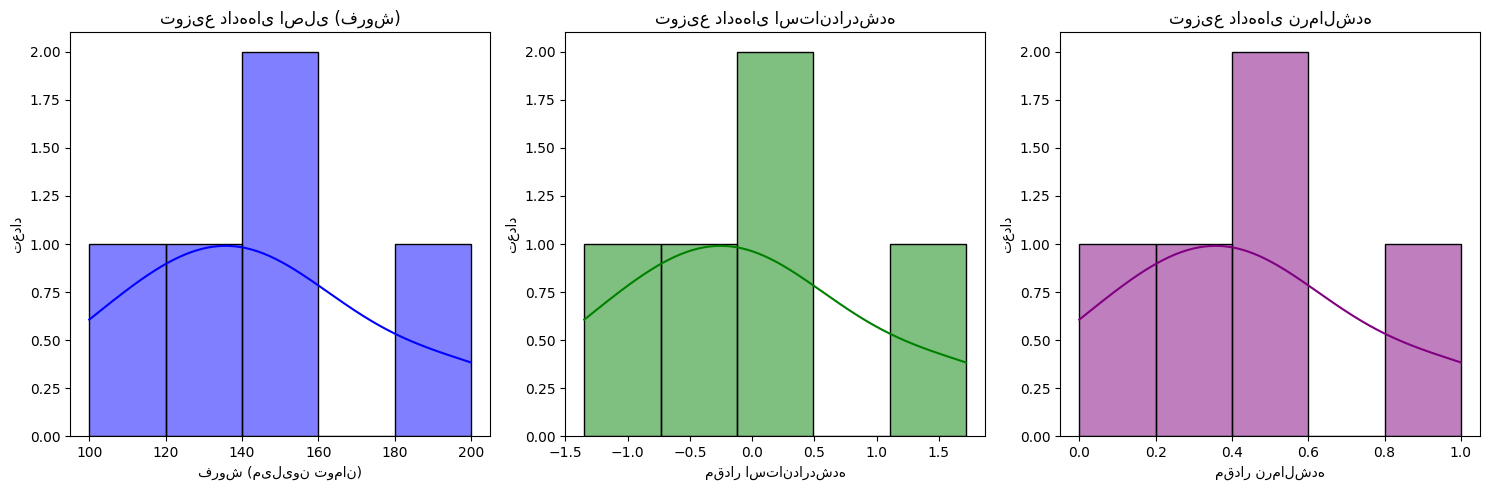

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# داده‌های نمونه
data = pd.DataFrame({
    'فروش': [100, 150, 130, 200, 140]
})

# استانداردسازی
scaler = StandardScaler()
data['فروش_استاندارد'] = scaler.fit_transform(data[['فروش']])

# نرمالسازی
minmax = MinMaxScaler()
data['فروش_نرمال'] = minmax.fit_transform(data[['فروش']])

print("داده‌ها:\n", data)

# رسم هیستوگرام مقایسه‌ای
plt.figure(figsize=(15, 5))

# هیستوگرام داده اصلی
plt.subplot(1, 3, 1)
sns.histplot(data['فروش'], bins=5, color='blue', kde=True)
plt.title('توزیع داده‌های اصلی (فروش)')
plt.xlabel('فروش (میلیون تومان)')
plt.ylabel('تعداد')

# هیستوگرام داده استانداردشده
plt.subplot(1, 3, 2)
sns.histplot(data['فروش_استاندارد'], bins=5, color='green', kde=True)
plt.title('توزیع داده‌های استانداردشده')
plt.xlabel('مقدار استانداردشده')
plt.ylabel('تعداد')

# هیستوگرام داده نرمال‌شده
plt.subplot(1, 3, 3)
sns.histplot(data['فروش_نرمال'], bins=5, color='purple', kde=True)
plt.title('توزیع داده‌های نرمال‌شده')
plt.xlabel('مقدار نرمال‌شده')
plt.ylabel('تعداد')

plt.tight_layout()
plt.show()

## ۵. ساخت ستون جدید، `map` و `apply` در Pandas

<div dir="rtl" style="text-align: right;">

### ۵.۱. ساخت ستون جدید
می‌توانید ستون‌های جدید را بر اساس محاسبات یا شرایط ایجاد کنید.

**مثال**: افزودن ستون "وضعیت فروش" بر اساس مقدار فروش.
<div/>

<div dir="rtl" style="text-align: right;">

### ۵.۲. استفاده از `map`
تابع `map` برای اعمال یک تابع یا دیکشنری به یک ستون (Series) استفاده می‌شود.
<div/>

<div dir="rtl" style="text-align: right;">

### ۵.۳. استفاده از `apply`
تابع `apply` برای اعمال یک تابع به ردیف‌ها یا ستون‌های DataFrame استفاده می‌شود.
<div/>

In [ ]:
import pandas as pd

# داده‌های نمونه
data = pd.DataFrame({
    'نام': ['علی', 'مریم', 'رضا', 'سارا'],
    'فروش': [100, 150, 80, 200]
})

# ساخت ستون جدید
data['فروش_دوبرابر'] = data['فروش'] * 2

# استفاده از map برای دسته‌بندی
data['وضعیت'] = data['فروش'].map(lambda x: 'بالا' if x >= 150 else 'پایین')

# استفاده از apply برای محاسبه پیچیده
def categorize_row(row):
    if row['فروش'] > 100 and row['نام'].startswith('م'):
        return 'ویژه'
    return 'عادی'

data['دسته‌بندی'] = data.apply(categorize_row, axis=1)

print("داده‌ها:\n", data)

<div dir="rtl" style="text-align: right;">

**خروجی**:
```
داده‌ها:
     نام  فروش  فروش_دوبرابر  وضعیت  دسته‌بندی
0   علی   100          200   پایین      عادی
1  مریم   150          300    بالا       ویژه
2   رضا    80          160   پایین      عادی
3  سارا   200          400    بالا      عادی
```

**نکته تدریسی**: از دانشجویان بخواهید ستون‌های جدیدی بر اساس شرایط واقعی (مثل دسته‌بندی مشتریان) ایجاد کنند.

---
<div/>